# Reading external data & Plotting

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

Esta expresión **%matplotlib inline** no es Python estandar, es un comando magic de Jupyter Notebook que le dice a Jupyter que los gráficos de Matplotlib se muestren incrustados dentro del notebook debajo de la celda donde se generan, en lugar de abrirse en una ventana externa

In [3]:
# Ayuda de la función
pd.read_csv?

Signature:
pd.read_csv(
    filepath_or_buffer: 'FilePath | ReadCsvBuffer[bytes] | ReadCsvBuffer[str]',
    *,
    sep: 'str | None | lib.NoDefault' = <no_default>,
    delimiter: 'str | None | lib.NoDefault' = None,
    header: "int | Sequence[int] | None | Literal['infer']" = 'infer',
    names: 'Sequence[Hashable] | None | lib.NoDefault' = <no_default>,
    index_col: 'IndexLabel | Literal[False] | None' = None,
    usecols: 'UsecolsArgType' = None,
    dtype: 'DtypeArg | None' = None,
    engine: 'CSVEngine | None' = None,
    converters: 'Mapping[Hashable, Callable] | None' = None,
    true_values: 'list | None' = None,
    false_values: 'list | None' = None,
    skipinitialspace: 'bool' = False,
    skiprows: 'list[int] | int | Callable[[Hashable], bool] | None' = None,
    skipfooter: 'int' = 0,
    nrows: 'int | None' = None,
    na_values: 'Hashable | Iterable[Hashable] | Mapping[Hashable, Iterable[Hashable]] | None' = None,
    keep_default_na: 'bool' = True,
    na_filter: '

In [4]:
df = pd.read_csv('data/btc-market-price.csv', header=None)

In [5]:
df.head()

,0,1
0,2017-04-02 00:00:00,1099.169125
1,2017-04-03 00:00:00,1141.813000
2,2017-04-04 00:00:00,1141.600363
3,2017-04-05 00:00:00,1133.079314
4,2017-04-06 00:00:00,1196.307937


Este archivo CSV tiene solo dos columnas *timestamp* y *precio*. No tiene una cabecera, contiene esapcios en blanco y tiene valores separados por comas. Pandas automáticamente asigna la primera fila de datos como cabecera lo cual es incorrecto. Podemos sobreescribir este comportamiento con el parámetro ***header***

In [6]:
df.columns = ['Timestamp', 'Price']

In [7]:
df.shape

(365, 2)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Timestamp  365 non-null    object 
 1   Price      365 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.8+ KB


In [9]:
df.head()

,Timestamp,Price
0,2017-04-02 00:00:00,1099.169125
1,2017-04-03 00:00:00,1141.813000
2,2017-04-04 00:00:00,1141.600363
3,2017-04-05 00:00:00,1133.079314
4,2017-04-06 00:00:00,1196.307937


In [10]:
df.tail() # Muestra las últimas filas

,Timestamp,Price
360,2018-03-28 00:00:00,7960.380000
361,2018-03-29 00:00:00,7172.280000
362,2018-03-30 00:00:00,6882.531667
363,2018-03-31 00:00:00,6935.480000
364,2018-04-01 00:00:00,6794.105000


A continuación podemos ver que la columna *Timestamp* no esta parseada apropiadamente como **date** sino mas bien esta parseada como un objeto String lo cual no queremos 

In [11]:
df.dtypes

Timestamp     object
Price        float64
dtype: object

Para solucionar el problema anterior vamos a usar la función pd.to_datetime

In [12]:
pd.to_datetime(df['Timestamp']).head() 

0   2017-04-02
1   2017-04-03
2   2017-04-04
3   2017-04-05
4   2017-04-06
Name: Timestamp, dtype: datetime64[ns]

In [13]:
df['Timestamp'] = pd.to_datetime(df['Timestamp']) # Acá si se aplica el cambio

In [14]:
df.head()

,Timestamp,Price
0,2017-04-02,1099.169125
1,2017-04-03,1141.813000
2,2017-04-04,1141.600363
3,2017-04-05,1133.079314
4,2017-04-06,1196.307937


In [15]:
df.dtypes # Ahora verificamos que realment se haya hecho la conversión

Timestamp    datetime64[ns]
Price               float64
dtype: object

La columna *Timestamp* se ve como el indice del DataFrame: date > price. Podemos cambiar el ID autoincremental generado por Pandas y usar la columna Timestamp DS como indice

In [16]:
df.set_index('Timestamp', inplace = True)

In [17]:
df.head()

,Price
Timestamp,
2017-04-02,1099.169125
2017-04-03,1141.813000
2017-04-04,1141.600363
2017-04-05,1133.079314
2017-04-06,1196.307937


Ahora vamos a ver el precio del bitcoin en fecha 2017-09-29

In [18]:
df.loc['2017-09-29']

Price    4193.574667
Name: 2017-09-29 00:00:00, dtype: float64

La función **read_csv** es tan poderosa que puedes especificar muchos parámetros al momento de importar. Podemos lograr los mismo resultados con solo una linea

In [19]:
df2 = pd.read_csv(
    'data/btc-market-price.csv',
    header = None, # Le a Pandas que el archivo no tiene fila de encabezados
    names = ['Timestamp', 'Price'], # Como el archivo no tiene encabezados, aca se define manualmente los nombres de columnas
    index_col = 0, # Indica que la columna 0 (primera columna) será el indice del DataFrame
    parse_dates = True # Le dice a Pandas que intente convertir el indice (que es la columna 0) a tipo fecha (datetime)
)

In [20]:
df2.head()

,Price
Timestamp,
2017-04-02,1099.169125
2017-04-03,1141.813000
2017-04-04,1141.600363
2017-04-05,1133.079314
2017-04-06,1196.307937


## Conceptos básicos de Trazado

Pandas integra Matplotlib y crea un gráfico simple como el siguiente

<Axes: xlabel='Timestamp'>

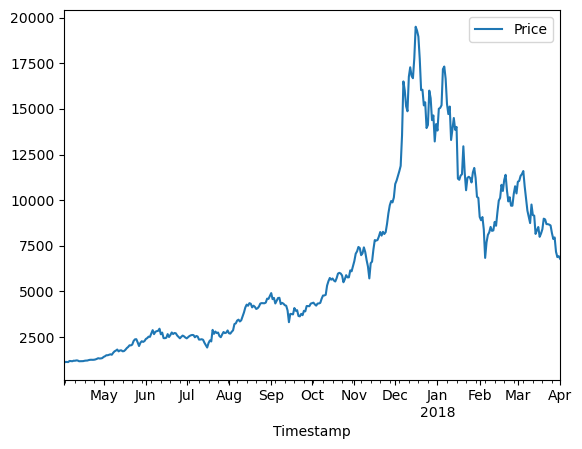

In [22]:
df.plot()

Detras de bastidores usa la interface matplotlib.pyplot. Podemos crear una gráfico similar con la función **plt.plot()**

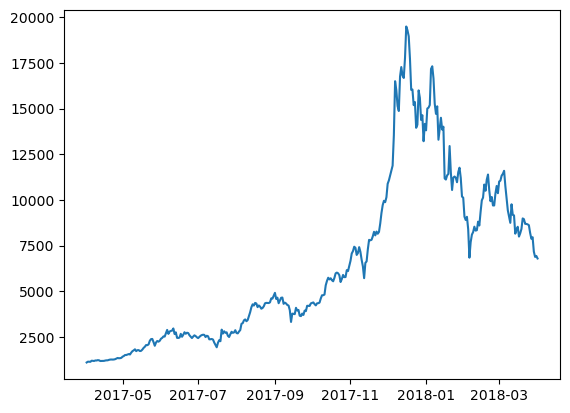

In [23]:
plt.plot(df.index, df['Price'])

**plt.plot()** acepta muchos parámetros, pero los dos primeros, son los que corresponden al **eje X** y **eje Y**